In [1]:
import warnings

In [2]:
warnings.filterwarnings("ignore")

In [3]:
import pandas as pd

In [4]:
from sklearn.model_selection import train_test_split

In [5]:
# Load Pima Indians Diabetes dataset
pima_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

In [6]:
pima_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

In [7]:
pima_df = pd.read_csv(pima_url, header=None, names=pima_cols)

In [10]:
X_pima = pima_df[pima_cols[:-1]]

In [11]:
y_pima = pima_df['Outcome']

In [12]:
# Split into 80% train and 20% test partition
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_pima, y_pima, test_size=0.20, stratify=y_pima, random_state=42
)

In [9]:
print("Pima Classification Training Set Shape:", X_train_c.shape)
print("Pima Classification Test Set Shape:", X_test_c.shape)

Pima Classification Training Set Shape: (614, 8)
Pima Classification Test Set Shape: (154, 8)


In [13]:
from sklearn.tree import DecisionTreeClassifier

In [14]:
from sklearn.metrics import accuracy_score, classification_report

In [15]:
# Initialize Decision Tree Classifier with depth regularization
tree_clf = DecisionTreeClassifier(max_depth=4, random_state=42)

In [16]:
tree_clf.fit(X_train_c, y_train_c)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [17]:
# Evaluate performance
clf_preds = tree_clf.predict(X_test_c)

In [18]:
print(f"Decision Tree Classifier Test Accuracy: {accuracy_score(y_test_c, clf_preds) * 100:.2f}%\n")

Decision Tree Classifier Test Accuracy: 79.87%



In [19]:
print("--- Classification Report ---")
print(classification_report(y_test_c, clf_preds, target_names=['No Diabetes (0)', 'Diabetes (1)']))

--- Classification Report ---
                 precision    recall  f1-score   support

No Diabetes (0)       0.82      0.88      0.85       100
   Diabetes (1)       0.74      0.65      0.69        54

       accuracy                           0.80       154
      macro avg       0.78      0.76      0.77       154
   weighted avg       0.80      0.80      0.80       154



In [20]:
import matplotlib.pyplot as plt

In [21]:
from sklearn.tree import plot_tree

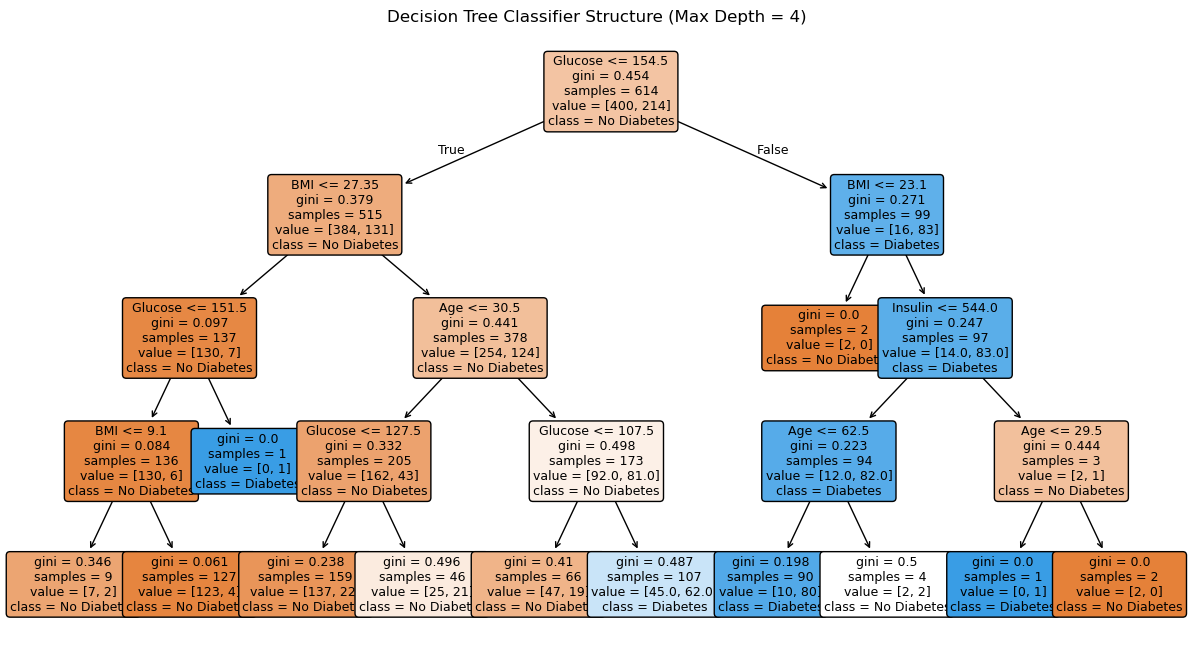

In [24]:
# Plot tree structure
plt.figure(figsize=(15, 8))
plot_tree(
    tree_clf, 
    feature_names=pima_cols[:-1], 
    class_names=['No Diabetes', 'Diabetes'], 
    filled=True, 
    rounded=True, 
    fontsize=9
)
plt.title("Decision Tree Classifier Structure (Max Depth = 4)")
plt.show()

In [25]:
from sklearn.tree import DecisionTreeRegressor

In [26]:
from sklearn.preprocessing import StandardScaler

In [27]:
# Load the Boston Housing dataset from public CSV repository
boston_url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"

In [28]:
boston_df = pd.read_csv(boston_url)

In [29]:
boston_features = [col for col in boston_df.columns if col != 'medv']

In [30]:
X_boston = boston_df[boston_features]

In [32]:
y_boston = boston_df['medv']

In [33]:
# Train-test split
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_boston, y_boston, test_size=0.20, random_state=42)

In [34]:
# Standardize features
scaler_r = StandardScaler()

In [35]:
X_train_r_scaled = scaler_r.fit_transform(X_train_r)

In [36]:
X_test_r_scaled = scaler_r.transform(X_test_r)

In [37]:
# Initialize and train Decision Tree Regressor
tree_reg = DecisionTreeRegressor(max_depth=5, random_state=42)

In [38]:
tree_reg.fit(X_train_r_scaled, y_train_r)

,criterion,'squared_error'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [39]:
print("Decision Tree Regressor trained successfully. Max Depth set to 5.")

Decision Tree Regressor trained successfully. Max Depth set to 5.


In [41]:
from sklearn.metrics import mean_squared_error, r2_score

In [42]:
import numpy as np

In [43]:
# Predict and compute metrics
reg_preds = tree_reg.predict(X_test_r_scaled)

In [44]:
mse_val = mean_squared_error(y_test_r, reg_preds)

In [45]:
rmse_val = np.sqrt(mse_val)

In [46]:
r2_val = r2_score(y_test_r, reg_preds)

In [47]:
print(f"Mean Squared Error (MSE): {mse_val:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_val:.4f} ($1000s)")
print(f"R2 Coefficient of Determination: {r2_val:.4f}\n")

Mean Squared Error (MSE): 8.5539
Root Mean Squared Error (RMSE): 2.9247 ($1000s)
R2 Coefficient of Determination: 0.8834



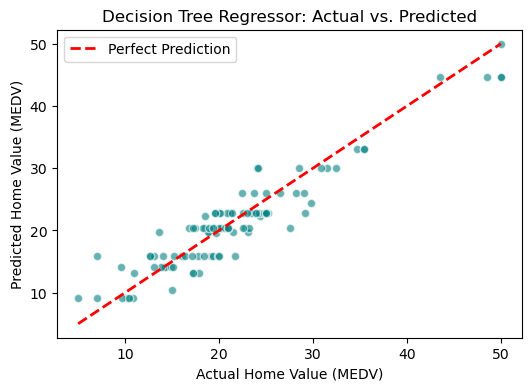

In [48]:
# Plot Actual vs Predicted values
plt.figure(figsize=(6, 4))
plt.scatter(y_test_r, reg_preds, color='teal', alpha=0.6, edgecolor='white')
plt.plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title("Decision Tree Regressor: Actual vs. Predicted")
plt.xlabel("Actual Home Value (MEDV)")
plt.ylabel("Predicted Home Value (MEDV)")
plt.legend()
plt.show()

In [49]:
import warnings

In [50]:
warnings.filterwarnings("ignore")

In [51]:
import pandas as pd

In [52]:
from sklearn.model_selection import train_test_split

In [53]:
from sklearn.preprocessing import StandardScaler

In [54]:
# Load Sonar dataset
sonar_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/sonar.csv"

In [55]:
sonar_features = [f"F_{i}" for i in range(1, 61)]

In [56]:
sonar_columns = sonar_features + ['Class']

In [57]:
sonar_df = pd.read_csv(sonar_url, header=None, names=sonar_columns)

In [58]:
# Encode class: M -> 1, R -> 0
sonar_df['Class_numeric'] = sonar_df['Class'].map({'M': 1, 'R': 0})

In [59]:
X_sonar = sonar_df[sonar_features]

In [60]:
y_sonar = sonar_df['Class_numeric']

In [61]:
# Scale features
scaler_sonar = StandardScaler()

In [62]:
X_sonar_scaled = scaler_sonar.fit_transform(X_sonar)

In [63]:
# Split into train/test validation partitions
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_sonar_scaled, y_sonar, test_size=0.30, stratify=y_sonar, random_state=42
)

In [64]:
print("Sonar Training Set Shape:", X_train_s.shape)
print("Sonar Test Set Shape:", X_test_s.shape)

Sonar Training Set Shape: (145, 60)
Sonar Test Set Shape: (63, 60)


In [65]:
from sklearn.ensemble import BaggingClassifier

In [66]:
from sklearn.metrics import accuracy_score

In [67]:
# Initialize and train Bagging Classifier
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

In [68]:
bagging_model.fit(X_train_s, y_train_s)

,estimator,DecisionTreeC...ndom_state=42)
,n_estimators,50
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,-1
,random_state,42
,verbose,0


In [69]:
# Evaluate accuracy
bagging_preds = bagging_model.predict(X_test_s)

In [70]:
bagging_accuracy = accuracy_score(y_test_s, bagging_preds)

In [71]:
print(f"Bagging Classifier Test Accuracy: {bagging_accuracy * 100:.2f}%")

Bagging Classifier Test Accuracy: 80.95%


In [72]:
from sklearn.ensemble import RandomForestClassifier

In [73]:
# Initialize and train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

In [74]:
rf_model.fit(X_train_s, y_train_s)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [75]:
# Evaluate accuracy
rf_preds = rf_model.predict(X_test_s)

In [76]:
rf_accuracy = accuracy_score(y_test_s, rf_preds)

In [77]:
print(f"Random Forest Classifier Test Accuracy: {rf_accuracy * 100:.2f}%")

Random Forest Classifier Test Accuracy: 82.54%


In [78]:
from sklearn.ensemble import VotingClassifier

In [79]:
from sklearn.linear_model import LogisticRegression

In [80]:
from sklearn.svm import SVC

In [81]:
# Define base estimators
estimators = [
    ('lr', LogisticRegression(max_iter=500, random_state=42)),
    ('dt', DecisionTreeClassifier(max_depth=5, random_state=42)),
    ('svc', SVC(probability=True, random_state=42))
]

In [82]:
# Initialize and train soft Voting Classifier
voting_model = VotingClassifier(estimators=estimators, voting='soft', n_jobs=-1)

In [83]:
voting_model.fit(X_train_s, y_train_s)

,estimators,"[('lr', ...), ('dt', ...), ...]"
,voting,'soft'
,weights,None
,n_jobs,-1
,flatten_transform,True
,verbose,False
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True


In [84]:
# Evaluate accuracy
voting_preds = voting_model.predict(X_test_s)

In [85]:
voting_accuracy = accuracy_score(y_test_s, voting_preds)

In [86]:
print(f"Voting Classifier Test Accuracy: {voting_accuracy * 100:.2f}%")

Voting Classifier Test Accuracy: 87.30%


In [87]:
import matplotlib.pyplot as plt

In [88]:
import seaborn as sns

In [89]:
# Compile results
ensemble_results = pd.DataFrame({
    'Ensemble Technique': ['Bagging (DT Base)', 'Random Forest', 'Voting Classifier (Soft)'],
    'Test Accuracy (%)': [bagging_accuracy * 100, rf_accuracy * 100, voting_accuracy * 100]
})

In [90]:
print("--- Performance Comparison ---")
print(ensemble_results.to_string(index=False))

--- Performance Comparison ---
      Ensemble Technique  Test Accuracy (%)
       Bagging (DT Base)          80.952381
           Random Forest          82.539683
Voting Classifier (Soft)          87.301587


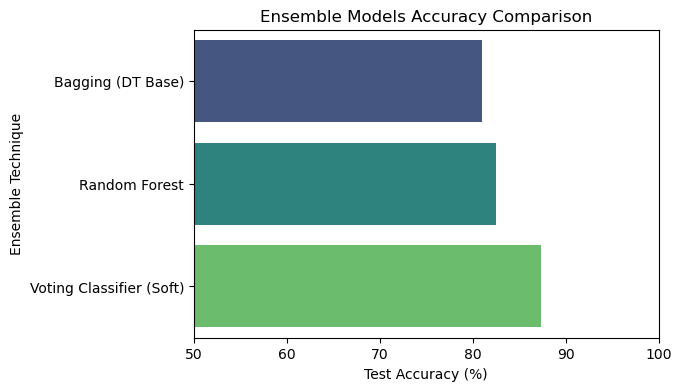

In [91]:
# Plot comparative bar chart
plt.figure(figsize=(6, 4))
sns.barplot(data=ensemble_results, x='Test Accuracy (%)', y='Ensemble Technique', palette='viridis')
plt.xlim([50, 100])
plt.title("Ensemble Models Accuracy Comparison")
plt.show()

In [92]:
import warnings

In [93]:
warnings.filterwarnings("ignore")

In [94]:
from sklearn.ensemble import AdaBoostClassifier

In [95]:
from sklearn.metrics import accuracy_score

In [96]:
# Initialize and train AdaBoost Classifier (with default Decision Tree stumps)
adaboost_model = AdaBoostClassifier(n_estimators=50, random_state=42)

In [97]:
adaboost_model.fit(X_train_s, y_train_s)

,estimator,None
,n_estimators,50
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,42


In [98]:
# Evaluate accuracy
ada_preds = adaboost_model.predict(X_test_s)

In [99]:
ada_accuracy = accuracy_score(y_test_s, ada_preds)

In [100]:
print(f"AdaBoost Classifier Test Accuracy: {ada_accuracy * 100:.2f}%")

AdaBoost Classifier Test Accuracy: 85.71%


In [101]:
from sklearn.ensemble import GradientBoostingClassifier

In [102]:
# Initialize and train a baseline Gradient Boosting Classifier
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)

In [103]:
gb_model.fit(X_train_s, y_train_s)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [104]:
# Evaluate accuracy
gb_preds = gb_model.predict(X_test_s)

In [105]:
gb_accuracy = accuracy_score(y_test_s, gb_preds)

In [106]:
print(f"Gradient Boosting Classifier Test Accuracy: {gb_accuracy * 100:.2f}%")

Gradient Boosting Classifier Test Accuracy: 80.95%


In [107]:
from sklearn.model_selection import GridSearchCV

In [108]:
# Define parameter grid for Gradient Boosting
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 4, 5]
}

In [109]:
# Run Grid Search
grid_gb = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

In [110]:
grid_gb.fit(X_train_s, y_train_s)

,estimator,GradientBoost...ndom_state=42)
,param_grid,"{'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], 'n_estimators': [50, 100, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'log_loss'


In [111]:
# Extract optimized model and predict
best_gb = grid_gb.best_estimator_

In [112]:
tuned_gb_preds = best_gb.predict(X_test_s)

In [113]:
tuned_gb_accuracy = accuracy_score(y_test_s, tuned_gb_preds)

In [114]:
print("Optimal Hyperparameters Selected:", grid_search_params := grid_gb.best_params_)
print(f"Tuned Gradient Boosting Test Accuracy: {tuned_gb_accuracy * 100:.2f}%")

Optimal Hyperparameters Selected: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 150}
Tuned Gradient Boosting Test Accuracy: 79.37%


In [115]:
# Assemble master performance records
master_comparison = pd.DataFrame({
    'Model Classifier': [
        'Bagging Classifier', 
        'Random Forest Classifier', 
        'Voting Ensemble (Soft)', 
        'AdaBoost Classifier', 
        'Base Gradient Boosting', 
        'Tuned Gradient Boosting'
    ],
    'Accuracy (%)': [
        bagging_accuracy * 100, 
        rf_accuracy * 100, 
        voting_accuracy * 100, 
        ada_accuracy * 100, 
        gb_accuracy * 100, 
        tuned_gb_accuracy * 100
    ]
}).sort_values(by='Accuracy (%)', ascending=False)

In [116]:
print("--- Master Performance Table: Tasks 2 & 3 ---")
print(master_comparison.to_string(index=False))

--- Master Performance Table: Tasks 2 & 3 ---
        Model Classifier  Accuracy (%)
  Voting Ensemble (Soft)     87.301587
     AdaBoost Classifier     85.714286
Random Forest Classifier     82.539683
      Bagging Classifier     80.952381
  Base Gradient Boosting     80.952381
 Tuned Gradient Boosting     79.365079


In [117]:
import matplotlib.pyplot as plt

In [118]:
import numpy as np

In [119]:
# Extract feature importances
rf_importances = rf_model.feature_importances_

In [120]:
gb_importances = best_gb.feature_importances_

In [121]:
# Isolate top 10 features for both models
top_indices_rf = np.argsort(rf_importances)[-10:]

In [122]:
top_indices_gb = np.argsort(gb_importances)[-10:]

In [123]:
# Define the standard 60-feature names list cleanly
features_list = [f"F_{i}" for i in range(1, 61)]

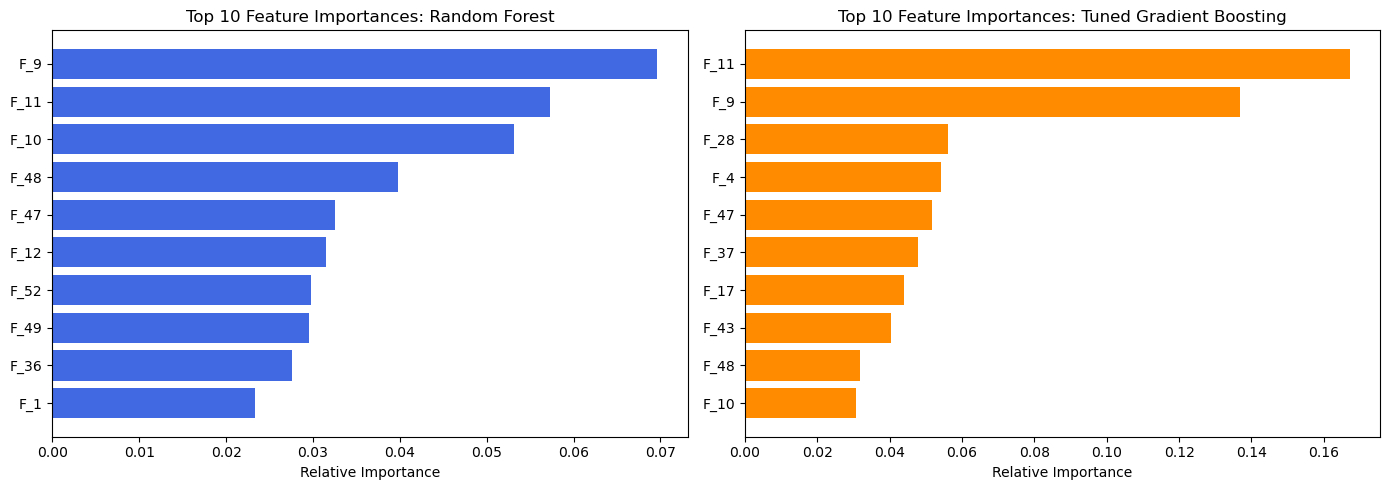

In [126]:
# Set up canvas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Plot Random Forest Importances
axes[0].barh(range(10), rf_importances[top_indices_rf], color='royalblue', align='center')
axes[0].set_yticks(range(10))
axes[0].set_yticklabels([features_list[i] for i in top_indices_rf])
axes[0].set_title("Top 10 Feature Importances: Random Forest")
axes[0].set_xlabel("Relative Importance")

# Plot Tuned Gradient Boosting Importances
axes[1].barh(range(10), gb_importances[top_indices_gb], color='darkorange', align='center')
axes[1].set_yticks(range(10))
axes[1].set_yticklabels([features_list[i] for i in top_indices_gb])
axes[1].set_title("Top 10 Feature Importances: Tuned Gradient Boosting")
axes[1].set_xlabel("Relative Importance")

plt.tight_layout()
plt.show()

In [5]:
# STEP 1: Import Required Libraries
import warnings

In [6]:
warnings.filterwarnings("ignore")

In [7]:
import pandas as pd

In [8]:
import matplotlib.pyplot as plt

In [9]:
import seaborn as sns

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
from sklearn.preprocessing import StandardScaler

In [12]:
from sklearn.tree import DecisionTreeClassifier

In [13]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, VotingClassifier

In [14]:
from sklearn.linear_model import LogisticRegression

In [15]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [16]:
# ==========================================================
# STEP 2: Load Titanic Dataset
# ==========================================================

titanic_url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

In [17]:
titanic_df = pd.read_csv(titanic_url)

In [18]:
print("Original Titanic Dataset Shape:", titanic_df.shape)
print(titanic_df.head())

Original Titanic Dataset Shape: (891, 12)
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0     

In [19]:
# ==========================================================
# STEP 3: Handle Missing Values
# ==========================================================

titanic_df["Age"] = titanic_df["Age"].fillna(titanic_df["Age"].median())
titanic_df["Embarked"] = titanic_df["Embarked"].fillna(titanic_df["Embarked"].mode()[0])

In [20]:
# ==========================================================
# STEP 4: Drop Unnecessary Columns
# ==========================================================

titanic_df.drop(
    columns=["Cabin", "Ticket", "Name", "PassengerId"],
    inplace=True
)

In [21]:
# ==========================================================
# STEP 5: Encode Categorical Features
# ==========================================================

titanic_df["Sex"] = titanic_df["Sex"].map({"male": 0, "female": 1})

titanic_df = pd.get_dummies(
    titanic_df,
    columns=["Embarked"],
    drop_first=True,
    dtype=int
)

In [22]:
print("\nMissing Values After Cleaning")
print(titanic_df.isnull().sum())

print("\nProcessed Dataset")
print(titanic_df.head())


Missing Values After Cleaning
Survived      0
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked_Q    0
Embarked_S    0
dtype: int64

Processed Dataset
   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked_Q  Embarked_S
0         0       3    0  22.0      1      0   7.2500           0           1
1         1       1    1  38.0      1      0  71.2833           0           0
2         1       3    1  26.0      0      0   7.9250           0           1
3         1       1    1  35.0      1      0  53.1000           0           1
4         0       3    0  35.0      0      0   8.0500           0           1


In [24]:
# ==========================================================
# STEP 6: Separate Features and Target
# ==========================================================

X = titanic_df.drop("Survived", axis=1)
y = titanic_df["Survived"]

In [23]:
# ==========================================================
# STEP 7: Split Dataset
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

In [25]:
print("\nTraining Set Shape :", X_train.shape)
print("Testing Set Shape  :", X_test.shape)


Training Set Shape : (712, 8)
Testing Set Shape  : (179, 8)


In [26]:
# ==========================================================
# STEP 8: Feature Scaling
# ==========================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [27]:
# ==========================================================
# STEP 9: Decision Tree Classifier
# ==========================================================

dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

In [37]:
dt_model.fit(X_train_scaled, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [38]:
dt_pred = dt_model.predict(X_test_scaled)

In [39]:
dt_acc = accuracy_score(y_test, dt_pred)

In [30]:
print("\n==============================")
print("Decision Tree Results")
print("==============================")

print(f"Accuracy : {dt_acc*100:.2f}%\n")

print(classification_report(
    y_test,
    dt_pred,
    target_names=["Did Not Survive", "Survived"]
))


Decision Tree Results
Accuracy : 77.65%

                 precision    recall  f1-score   support

Did Not Survive       0.79      0.87      0.83       110
       Survived       0.75      0.62      0.68        69

       accuracy                           0.78       179
      macro avg       0.77      0.75      0.76       179
   weighted avg       0.77      0.78      0.77       179



In [31]:
# ==========================================================
# STEP 10: Random Forest Classifier
# ==========================================================

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [33]:
rf_model.fit(X_train_scaled, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [34]:
rf_pred = rf_model.predict(X_test_scaled)

In [35]:
rf_acc = accuracy_score(y_test, rf_pred)

In [36]:
print("Random Forest Accuracy : {:.2f}%".format(rf_acc*100))

Random Forest Accuracy : 80.45%


In [40]:
# ==========================================================
# STEP 11: AdaBoost Classifier
# ==========================================================

try:
    ada_model = AdaBoostClassifier(
        n_estimators=100,
        random_state=42
    )
except:
    from sklearn.tree import DecisionTreeClassifier
    ada_model = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=100,
        random_state=42
    )

In [41]:
ada_model.fit(X_train_scaled, y_train)

,estimator,None
,n_estimators,100
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,42


In [42]:
ada_pred = ada_model.predict(X_test_scaled)

In [43]:
ada_acc = accuracy_score(y_test, ada_pred)

In [44]:
print("AdaBoost Accuracy : {:.2f}%".format(ada_acc*100))

AdaBoost Accuracy : 78.21%


In [45]:
# ==========================================================
# STEP 12: Voting Classifier
# ==========================================================

estimators = [

    ("lr", LogisticRegression(max_iter=500)),

    ("dt", DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    )),

    ("rf", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))

]

In [46]:
voting_model = VotingClassifier(
    estimators=estimators,
    voting="soft",
    n_jobs=-1
)

In [47]:
voting_model.fit(X_train_scaled, y_train)

,estimators,"[('lr', ...), ('dt', ...), ...]"
,voting,'soft'
,weights,None
,n_jobs,-1
,flatten_transform,True
,verbose,False
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True


In [48]:
vote_pred = voting_model.predict(X_test_scaled)

In [49]:
vote_acc = accuracy_score(y_test, vote_pred)

In [50]:
print("Voting Classifier Accuracy : {:.2f}%".format(vote_acc*100))

Voting Classifier Accuracy : 83.24%


In [51]:
# ==========================================================
# STEP 13: Compare All Models
# ==========================================================

results = pd.DataFrame({

    "Model": [
        "Decision Tree",
        "Random Forest",
        "AdaBoost",
        "Voting Classifier"
    ],

    "Accuracy (%)": [
        dt_acc * 100,
        rf_acc * 100,
        ada_acc * 100,
        vote_acc * 100
    ]

})

In [52]:
results = results.sort_values(
    by="Accuracy (%)",
    ascending=False
)

In [53]:
print("\n==============================")
print("Model Comparison")
print("==============================")

print(results.to_string(index=False))


Model Comparison
            Model  Accuracy (%)
Voting Classifier     83.240223
    Random Forest     80.446927
         AdaBoost     78.212291
    Decision Tree     77.653631


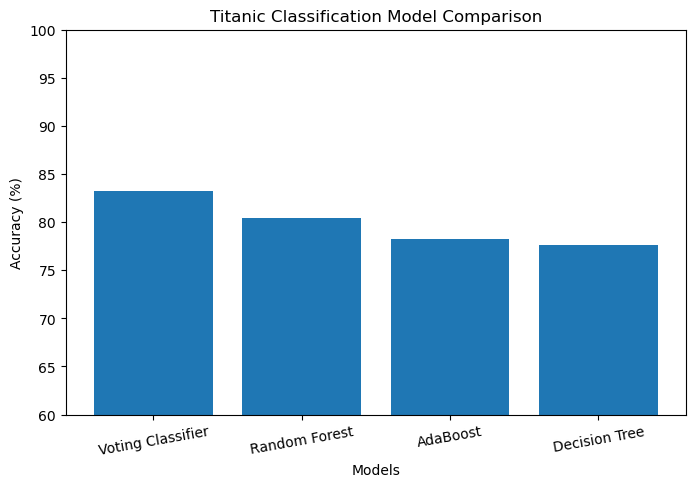

In [54]:
# ==========================================================
# STEP 14: Plot Accuracy Comparison
# ==========================================================

plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["Accuracy (%)"])

plt.title("Titanic Classification Model Comparison")

plt.xlabel("Models")

plt.ylabel("Accuracy (%)")

plt.ylim(60,100)

plt.xticks(rotation=10)

plt.show()

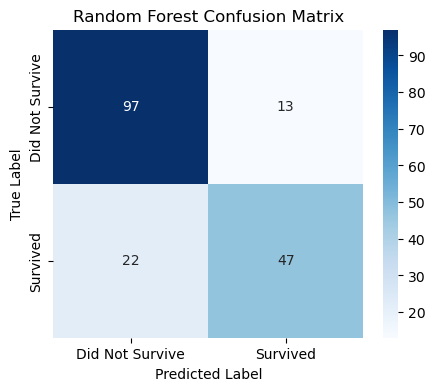

In [2]:
# ==========================================================
# STEP 15: Confusion Matrix
# ==========================================================

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Did Not Survive","Survived"],
    yticklabels=["Did Not Survive","Survived"]
)

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.show()